# Generating Canonical SMILES for Organometallic Compounds

There are some challenges associated with generating canonical SMILES and InChI strings for organometallic compounds.
- RDKit SMILES parsing fails for ChemDraw-generated SMILES of plainly drawn metal complexes due to valence rules on N atoms.
- Using dative bonds in ChemDraw fixes this problem but generates charged species to satisfy valence rules.
- ChemDraw's syntax for ferrocene complexes leads to RDKit parsing failures.
- PubChem "canonical" SMILES for metal complexes treat each substructure as a separate component (e.g., metals, ligands, ions), leading to a salt-like representation of the compounds.
- Many online sources of SMILES give the 'salt-like' representation used by PubChem.

Current best-practice is to:
1. Use ChemDraw (or other chemical drawing tool) to generate SMILES with neutral single bonds to ligands
2. Draw ferrocenes explicitly as cyclopentadienyl-anion-sandwiched Fe atoms
3. Generate dative '<-' bonds programmatically

The [set_dative_bonds](https://github.com/open-reaction-database/ord-schema/blob/2b41398aee0ea5aa5b6e5d3a80eddbbdd8dedec2/ord_schema/message_helpers.py#L613) message_helper in ord-schema can be used to perform step 3. This code is derived from work by Greg Landrum at RDKit: https://www.rdkit.org/docs/Cookbook.html#organometallics-with-dative-bonds. For an example of how this code is used in the preparation of an ORD dataset see https://github.com/open-reaction-database/ord-schema/tree/main/examples/submissions/1_Santanilla_Nanomole_HTE

## Required Packages

In [1]:
# Import packages
import pandas as pd
from rdkit import Chem

from ord_schema import message_helpers

## Generating a Single Canonical SMILES

In [2]:
# Enter your SMILES string here. Tested on SMILES strings from ChemDraw and ChemDoodle.
smiles = "O=S(C)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)C1=C2)[P](C(C=C1)=C(C(=C(C=C2)P(C(=CC=C3)C=C3)C(=CC=C3)C=C3)C(=C2C=C2)C=C2)C(=C1C=C1)C=C1)(C(C=CC1)=CC=1)C(=CC=C1)C=C1"  # from chemdoodle
# smiles = 'CS(O[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=C(C5=C(P(C6=CC=CC=C6)C7=CC=CC=C7)C=CC8=C5C=CC=C8)C(C=CC=C9)=C9C=C4)C%10=CC=CC=C%10C%11=C([NH2]1)C=CC=C%11)(=O)=O' # from chemdraw

In [3]:
# Use RDKit to generate a mol for the SMILES string
mol = Chem.MolFromSmiles(smiles, sanitize=False)
# Use the message_helper to add dative bonds to the mol
#     by default this converts excess bonds from "N" and "P" to dative bonds
#     to add dative bonding from other donors use the optional setting
#     'from_atoms = ("N", "P", ...)'
dative_mol = message_helpers.set_dative_bonds(mol)
# Use RDKit to conver the mol back to a SMILES and print the result
canonical_smiles = Chem.MolToSmiles(dative_mol)
print(canonical_smiles)

CS(=O)O[Pd]1(<-P(C2=CC=CC=C2)(C2=CC=CC=C2)C2=C(C3=C(P(C4=CC=CC=C4)C4=CC=CC=C4)C=CC4=C3C=CC=C4)C3=C(C=CC=C3)C=C2)<-NC2=C(C=CC=C2)C2=CC=CC=C21


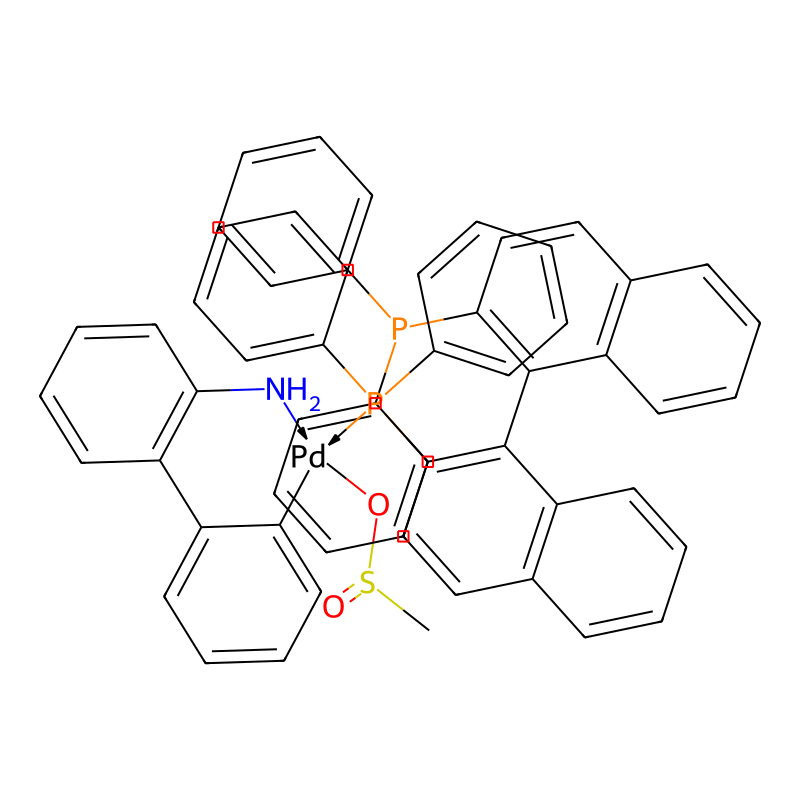

In [4]:
# Draw the RDKit mol to check it
Chem.rdDepictor.Compute2DCoords(dative_mol)
Chem.Draw.MolToImage(dative_mol, size=(800, 800))

## Batch Generating Canonical SMILES

In [5]:
# Read in a csv file containing SMILES strings to canonicalize
smiles_df = pd.read_csv("example_catalysts.csv")
smiles_df

,compound_name,chemdraw_smiles,chemdoodle_smiles
0,BINAP Pd G3 30,CS(O[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=C(C5...,O=S(C)(=O)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)...
1,DPPF Pd G3 31,CS(O[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=CC=C...,O=S(=O)(C)O[Pd]([NH2]C(C=CC1)=C2C=1)(C(=CC=C1)...
2,XantPhos Pd G2 32,Cl[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=C(OC(C...,Cl[Pd]([NH2]C1C=C2)(C(=CC3)C(=CC=3)C=1C=C2)[P]...
3,tBu3P Pd G2 33,Cl[Pd]1([P](C(C)(C)C)(C(C)(C)C)C(C)(C)C)C2=CC=...,Cl[Pd]([NH2]C1C=C2)(C(=CC3)C(C=1C=C2)=CC=3)[P]...
4,PPA Pd G3 34,CC(OC1(C)O2)(C3)OC(C)(C1)[P]([Pd]4(OS(C)(=O)=O...,O=S(=O)(C)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)...
5,Aphos Pd G3 35,NC(C=C1)=CC=C1[P]([Pd]2(OS(C)(=O)=O)C3=CC=CC=C...,NC(C=CC1[P]([Pd](OS(=O)(C)=O)([NH2]C2C=C3)C(=C...
6,Xphos Pd G3 36,CS(O[Pd]1([P](C2CCCCC2)(C3CCCCC3)C4=C(C5=C(C(C...,O=S(C)(=O)O[Pd]([NH2]C1C=C2)(C(=CC3)C(C=1C=C2)...
7,RuPhos Pd G2 37,Cl[Pd]1([P](C2CCCCC2)(C3CCCCC3)C4=C(C5=C(OC(C)...,Cl[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)C1=C2)[P]...
8,DTBPF Pd G3 38,CS(O[Pd]1([P](C(C)(C)C)(C(C)(C)C)C2=CC=CC2[Fe]...,O=S(=O)(C)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(C1=CC1)...
9,J009 Pd G3 39,CC(P(C(C)(C)C)C(C)(C)C)C1=C(C([Fe]C2C=CC=C2)C=...,O=S(C)(=O)O[Pd]([NH2]C1C=C2)(C(=CC=C3)C(=C3)C=...


In [6]:
# Iterate through the rows and generate canonical SMILES
canonical_smiles = []
for smiles in smiles_df["chemdoodle_smiles"]:
    mol = Chem.MolFromSmiles(smiles, sanitize=False)
    dative_mol = message_helpers.set_dative_bonds(mol)
    can_smiles = Chem.MolToSmiles(dative_mol)
    canonical_smiles.append(can_smiles)

In [7]:
# Add the canonical smiles back to the dataframe for future reference
smiles_df["canonical_chemdoodle_smiles"] = canonical_smiles
smiles_df

,compound_name,chemdraw_smiles,chemdoodle_smiles,canonical_chemdoodle_smiles
0,BINAP Pd G3 30,CS(O[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=C(C5...,O=S(C)(=O)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)...,CS(=O)(=O)O[Pd]1(<-P(C2=CC=CC=C2)(C2=CC=CC=C2)...
1,DPPF Pd G3 31,CS(O[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=CC=C...,O=S(=O)(C)O[Pd]([NH2]C(C=CC1)=C2C=1)(C(=CC=C1)...,CS(=O)(=O)O[Pd]1(<-P(C2=CC=CC=C2)(C2=CC=CC=C2)...
2,XantPhos Pd G2 32,Cl[Pd]1([P](C2=CC=CC=C2)(C3=CC=CC=C3)C4=C(OC(C...,Cl[Pd]([NH2]C1C=C2)(C(=CC3)C(=CC=3)C=1C=C2)[P]...,CC1(C)C2=CC=CC(P(C3=CC=CC=C3)(C3=CC=CC=C3)->[P...
3,tBu3P Pd G2 33,Cl[Pd]1([P](C(C)(C)C)(C(C)(C)C)C(C)(C)C)C2=CC=...,Cl[Pd]([NH2]C1C=C2)(C(=CC3)C(C=1C=C2)=CC=3)[P]...,CC(C)(C)P(C(C)(C)C)(C(C)(C)C)->[Pd]1(Cl)<-NC2=...
4,PPA Pd G3 34,CC(OC1(C)O2)(C3)OC(C)(C1)[P]([Pd]4(OS(C)(=O)=O...,O=S(=O)(C)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)...,CC12C[C@@]3(C)O[C@](C)(C[C@@](C)(O1)P3(C1=CC=C...
5,Aphos Pd G3 35,NC(C=C1)=CC=C1[P]([Pd]2(OS(C)(=O)=O)C3=CC=CC=C...,NC(C=CC1[P]([Pd](OS(=O)(C)=O)([NH2]C2C=C3)C(=C...,CC(C)(C)P(C1=CC=C(N)C=C1)(C(C)(C)C)->[Pd]1(OS(...
6,Xphos Pd G3 36,CS(O[Pd]1([P](C2CCCCC2)(C3CCCCC3)C4=C(C5=C(C(C...,O=S(C)(=O)O[Pd]([NH2]C1C=C2)(C(=CC3)C(C=1C=C2)...,CC(C)C1=CC(C(C)C)=C(C2=C(P(C3CCCCC3)(C3CCCCC3)...
7,RuPhos Pd G2 37,Cl[Pd]1([P](C2CCCCC2)(C3CCCCC3)C4=C(C5=C(OC(C)...,Cl[Pd]([NH2]C(=C1C=C2)C=C2)(C(=CC=C2)C1=C2)[P]...,CC(C)OC1=CC=CC(OC(C)C)=C1C1=C(P(C2CCCCC2)(C2CC...
8,DTBPF Pd G3 38,CS(O[Pd]1([P](C(C)(C)C)(C(C)(C)C)C2=CC=CC2[Fe]...,O=S(=O)(C)O[Pd]([NH2]C(=C1C=C2)C=C2)(C(C1=CC1)...,CC(C)(C)P(C1=CC=CC1[Fe]C1C=CC=C1P(C(C)(C)C)(C(...
9,J009 Pd G3 39,CC(P(C(C)(C)C)C(C)(C)C)C1=C(C([Fe]C2C=CC=C2)C=...,O=S(C)(=O)O[Pd]([NH2]C1C=C2)(C(=CC=C3)C(=C3)C=...,CC(C1=C(P(C2CCCCC2)(C2CCCCC2)->[Pd]2(OS(C)(=O)...


### Check dative bonds drawn on metal complexes

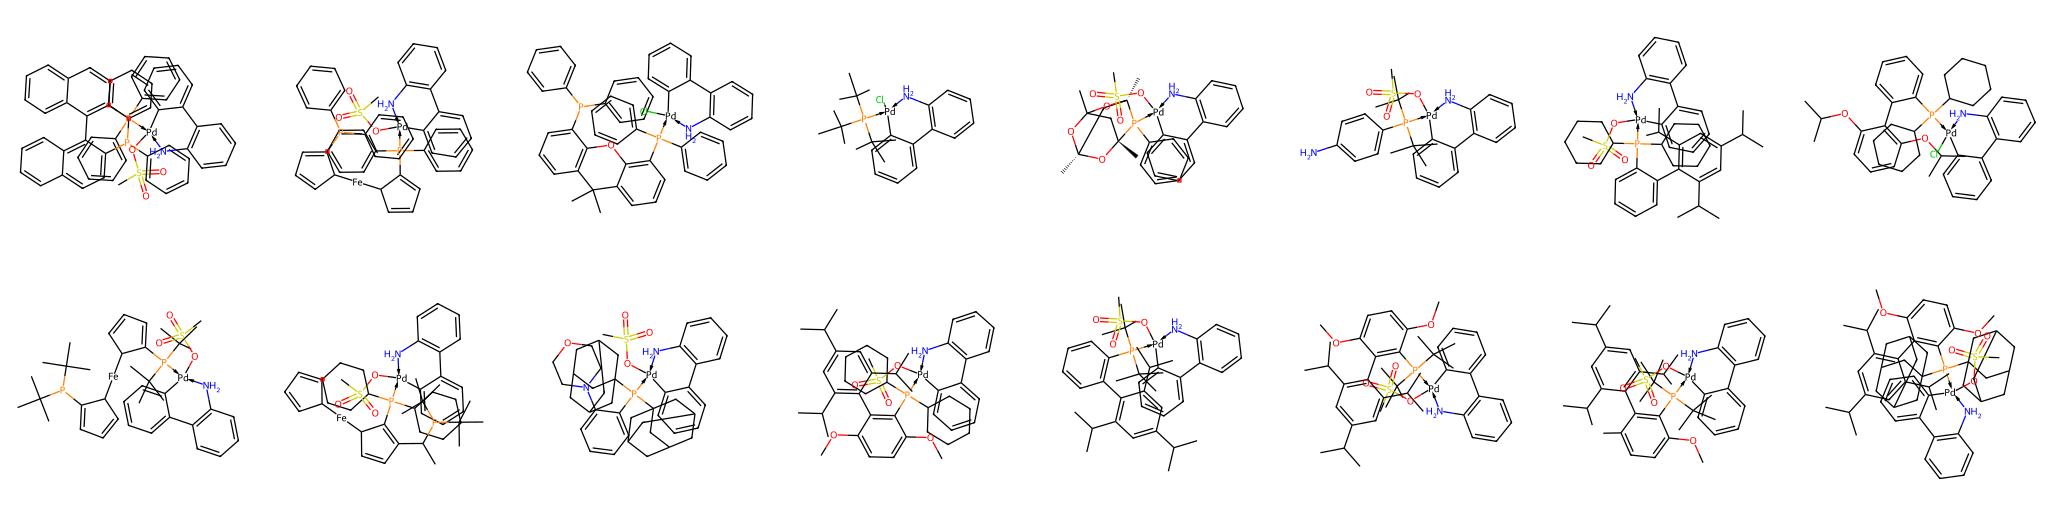

In [8]:
# Create list of mol objects
catalyst_mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_df["canonical_chemdoodle_smiles"]]
for mol in catalyst_mols:
    Chem.rdDepictor.Compute2DCoords(mol)

# Create grid drawing
# Can see neutral N, P, and Pd atoms with dative bonds from N and P to Pd
Chem.Draw.MolsToGridImage(catalyst_mols, molsPerRow=8, useSVG=True, subImgSize=(400, 400))

### Export the SMILES to csv

In [9]:
smiles_df.to_csv('output.csv')